# 1. Configuração do ambiente

Nesta etapa são instaladas as bibliotecas necessárias, montado o Google Drive e configurados os diretórios para armazenamento dos modelos, métricas, relatórios e arquivos gerados durante o projeto.

In [1]:
# ============================================================
# BLOCO 1 — Configuração do ambiente e diretórios
# ============================================================

# Instalação das bibliotecas necessárias
!pip install -q xgboost shap

# Montagem do Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Imports básicos
import os

# Diretórios do projeto
BASE_DIR = "/content/drive/MyDrive/tech_challenge_fase2"
REPORTS_DIR = os.path.join(BASE_DIR, "reports")
MODELS_DIR = os.path.join(BASE_DIR, "models")

# Criação das pastas
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print("Ambiente configurado com sucesso.")
print("Diretório base:", BASE_DIR)
print("Diretório de relatórios:", REPORTS_DIR)
print("Diretório de modelos:", MODELS_DIR)

Mounted at /content/drive
Ambiente configurado com sucesso.
Diretório base: /content/drive/MyDrive/tech_challenge_fase2
Diretório de relatórios: /content/drive/MyDrive/tech_challenge_fase2/reports
Diretório de modelos: /content/drive/MyDrive/tech_challenge_fase2/models


In [2]:
# ============================================================
# BLOCO 2 — Imports e configurações iniciais
# ============================================================

import os
import time
import warnings
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("Imports realizados com sucesso.")

Imports realizados com sucesso.


# 2. Carregamento e preparação do dataset

Nesta etapa é carregado o dataset de câncer de mama, com o objetivo de classificar os registros em benignos ou malignos. A variável alvo foi ajustada para representar a classe maligna como 1 e a classe benigna como 0.

In [3]:
# ============================================================
# BLOCO 3 — Carregamento do dataset
# ============================================================

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)

# No sklearn:
# target original: 0 = malignant, 1 = benign
# Vamos inverter para ficar mais intuitivo:
# 1 = maligno
# 0 = benigno
y = pd.Series(np.where(data.target == 0, 1, 0), name="diagnostico_maligno")

df = X.copy()
df["diagnostico_maligno"] = y

print("Shape da base:", df.shape)
display(df.head())

print("\nDistribuição da variável alvo:")
display(df["diagnostico_maligno"].value_counts().rename(index={0: "Benigno", 1: "Maligno"}))

# Salvar dataset usado
df.to_csv(os.path.join(REPORTS_DIR, "dataset_utilizado_fase2.csv"), index=False)

print("Dataset salvo em:", os.path.join(REPORTS_DIR, "dataset_utilizado_fase2.csv"))

Shape da base: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnostico_maligno
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1



Distribuição da variável alvo:


,count
diagnostico_maligno,
Benigno,357
Maligno,212


Dataset salvo em: /content/drive/MyDrive/tech_challenge_fase2/reports/dataset_utilizado_fase2.csv


In [4]:
# ============================================================
# BLOCO 4 — Separação treino e teste
# ============================================================

X = df.drop(columns=["diagnostico_maligno"])
y = df["diagnostico_maligno"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

print("\nDistribuição no treino:")
display(y_train.value_counts(normalize=True))

print("\nDistribuição no teste:")
display(y_test.value_counts(normalize=True))

Treino: (455, 30)
Teste: (114, 30)

Distribuição no treino:


,proportion
diagnostico_maligno,
0,0.626374
1,0.373626



Distribuição no teste:


,proportion
diagnostico_maligno,
0,0.631579
1,0.368421


# 3. Função de avaliação dos modelos

Nesta etapa é criada uma função padronizada para avaliar os modelos com métricas adequadas ao problema médico, incluindo accuracy, precision, recall, F1-score, ROC AUC, especificidade e matriz de confusão.

In [5]:
# ============================================================
# BLOCO 5 — Função de avaliação
# ============================================================

def avaliar_modelo(nome_modelo, modelo, X_test, y_test):
    """
    Avalia o modelo considerando o problema médico:
    1 = maligno
    0 = benigno
    """

    y_pred = modelo.predict(X_test)

    if hasattr(modelo, "predict_proba"):
        y_proba = modelo.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        y_proba = None
        roc_auc = np.nan

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)

    matriz = confusion_matrix(y_test, y_pred, labels=[0, 1])

    tn, fp, fn, tp = matriz.ravel()

    especificidade = tn / (tn + fp) if (tn + fp) > 0 else 0

    resultado = {
        "modelo": nome_modelo,
        "accuracy": acc,
        "precision_maligno": precision,
        "recall_maligno": recall,
        "f1_maligno": f1,
        "roc_auc": roc_auc,
        "especificidade_benigno": especificidade,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

    print(f"\n===== {nome_modelo} =====")
    print("Accuracy:", round(acc, 4))
    print("Precision maligno:", round(precision, 4))
    print("Recall maligno:", round(recall, 4))
    print("F1 maligno:", round(f1, 4))
    print("ROC AUC:", round(roc_auc, 4))
    print("Especificidade benigno:", round(especificidade, 4))

    print("\nMatriz de confusão:")
    print(matriz)

    print("\nRelatório de classificação:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Benigno", "Maligno"]
    ))

    return resultado

# 4. Treinamento dos modelos baseline

Nesta etapa são treinados os modelos originais, sem otimização por Algoritmo Genético, para criar uma base de comparação com os modelos otimizados.

In [6]:
# ============================================================
# BLOCO 6 — Treinamento dos modelos originais
# ============================================================

resultados_baseline = []

# Modelo 1 — Random Forest original
inicio = time.time()

rf_original = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

rf_original.fit(X_train, y_train)

tempo_rf = time.time() - inicio

resultado_rf = avaliar_modelo(
    "Random Forest Original",
    rf_original,
    X_test,
    y_test
)

resultado_rf["tempo_treino_segundos"] = tempo_rf
resultados_baseline.append(resultado_rf)


# Modelo 2 — XGBoost original
inicio = time.time()

xgb_original = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE
)

xgb_original.fit(X_train, y_train)

tempo_xgb = time.time() - inicio

resultado_xgb = avaliar_modelo(
    "XGBoost Original",
    xgb_original,
    X_test,
    y_test
)

resultado_xgb["tempo_treino_segundos"] = tempo_xgb
resultados_baseline.append(resultado_xgb)


# Consolidar resultados
df_resultados_baseline = pd.DataFrame(resultados_baseline)

display(df_resultados_baseline)

df_resultados_baseline.to_csv(
    os.path.join(REPORTS_DIR, "metricas_modelos_originais.csv"),
    index=False
)

print("Métricas salvas em:", os.path.join(REPORTS_DIR, "metricas_modelos_originais.csv"))


===== Random Forest Original =====
Accuracy: 0.9737
Precision maligno: 1.0
Recall maligno: 0.9286
F1 maligno: 0.963
ROC AUC: 0.9965
Especificidade benigno: 1.0

Matriz de confusão:
[[72  0]
 [ 3 39]]

Relatório de classificação:
              precision    recall  f1-score   support

     Benigno       0.96      1.00      0.98        72
     Maligno       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


===== XGBoost Original =====
Accuracy: 0.9649
Precision maligno: 1.0
Recall maligno: 0.9048
F1 maligno: 0.95
ROC AUC: 0.9944
Especificidade benigno: 1.0

Matriz de confusão:
[[72  0]
 [ 4 38]]

Relatório de classificação:
              precision    recall  f1-score   support

     Benigno       0.95      1.00      0.97        72
     Maligno       1.00      0.90      0.95        42

    accuracy                           0.96       114
  

,modelo,accuracy,precision_maligno,recall_maligno,f1_maligno,roc_auc,especificidade_benigno,tn,fp,fn,tp,tempo_treino_segundos
0,Random Forest Original,0.973684,1.0,0.928571,0.962963,0.996528,1.0,72,0,3,39,0.184747
1,XGBoost Original,0.964912,1.0,0.904762,0.950000,0.994378,1.0,72,0,4,38,0.128677


Métricas salvas em: /content/drive/MyDrive/tech_challenge_fase2/reports/metricas_modelos_originais.csv


# 5. Implementação do Algoritmo Genético

Nesta etapa é implementado o Algoritmo Genético para otimização dos hiperparâmetros do Random Forest. Cada indivíduo representa uma combinação de hiperparâmetros, e a função fitness prioriza métricas relevantes para o contexto médico, especialmente o recall da classe maligna.

In [7]:
# ============================================================
# BLOCO 7 — Separação interna para validação do Algoritmo Genético
# ============================================================

X_ga_train, X_ga_val, y_ga_train, y_ga_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("Treino GA:", X_ga_train.shape)
print("Validação GA:", X_ga_val.shape)

print("\nDistribuição validação GA:")
display(y_ga_val.value_counts())

Treino GA: (341, 30)
Validação GA: (114, 30)

Distribuição validação GA:


,count
diagnostico_maligno,
0,71
1,43


In [8]:
# ============================================================
# BLOCO 8 — Espaço de busca dos genes do Random Forest
# ============================================================

search_space_rf = {
    "n_estimators": [50, 100, 150, 200, 300],
    "max_depth": [None, 3, 5, 8, 10, 15],
    "min_samples_split": [2, 4, 6, 8, 10],
    "min_samples_leaf": [1, 2, 3, 4],
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced"]
}

print("Espaço de busca configurado:")
for gene, valores in search_space_rf.items():
    print(gene, "=>", valores)

Espaço de busca configurado:
n_estimators => [50, 100, 150, 200, 300]
max_depth => [None, 3, 5, 8, 10, 15]
min_samples_split => [2, 4, 6, 8, 10]
min_samples_leaf => [1, 2, 3, 4]
max_features => ['sqrt', 'log2', None]
class_weight => [None, 'balanced']


In [9]:
# ============================================================
# BLOCO 9 — Implementação do Algoritmo Genético
# ============================================================

import random

def criar_individuo(search_space):
    """
    Cria um indivíduo.
    Cada indivíduo é um conjunto de hiperparâmetros do Random Forest.
    """
    return {
        gene: random.choice(valores)
        for gene, valores in search_space.items()
    }


def calcular_metricas_ga(modelo, X_val, y_val):
    """
    Calcula métricas usadas na função fitness.
    """
    y_pred = modelo.predict(X_val)
    y_proba = modelo.predict_proba(X_val)[:, 1]

    acc = accuracy_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred, pos_label=1)
    f1 = f1_score(y_val, y_pred, pos_label=1)
    roc_auc = roc_auc_score(y_val, y_proba)

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred, labels=[0, 1]).ravel()
    especificidade = tn / (tn + fp) if (tn + fp) > 0 else 0

    return {
        "accuracy": acc,
        "recall_maligno": recall,
        "f1_maligno": f1,
        "roc_auc": roc_auc,
        "especificidade_benigno": especificidade,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }


def fitness_rf(individuo, X_train_fit, y_train_fit, X_val, y_val):
    """
    Função fitness.

    Como é um problema médico, o recall da classe maligna recebe maior peso,
    porque falso negativo é crítico: caso maligno classificado como benigno.
    """

    modelo = RandomForestClassifier(
        n_estimators=individuo["n_estimators"],
        max_depth=individuo["max_depth"],
        min_samples_split=individuo["min_samples_split"],
        min_samples_leaf=individuo["min_samples_leaf"],
        max_features=individuo["max_features"],
        class_weight=individuo["class_weight"],
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    modelo.fit(X_train_fit, y_train_fit)

    metricas = calcular_metricas_ga(modelo, X_val, y_val)

    fitness = (
        0.40 * metricas["recall_maligno"] +
        0.25 * metricas["f1_maligno"] +
        0.25 * metricas["roc_auc"] +
        0.10 * metricas["especificidade_benigno"]
    )

    return fitness, metricas


def selecao_torneio(populacao_avaliada, tamanho_torneio=3):
    """
    Seleção por torneio.
    Sorteia alguns indivíduos e retorna o melhor entre eles.
    """
    competidores = random.sample(populacao_avaliada, tamanho_torneio)
    competidores = sorted(competidores, key=lambda x: x["fitness"], reverse=True)
    return competidores[0]["individuo"]


def crossover_uniforme(pai1, pai2, taxa_crossover):
    """
    Crossover uniforme.
    Para cada gene, o filho herda de um dos pais.
    """
    if random.random() > taxa_crossover:
        return pai1.copy(), pai2.copy()

    filho1 = {}
    filho2 = {}

    for gene in pai1.keys():
        if random.random() < 0.5:
            filho1[gene] = pai1[gene]
            filho2[gene] = pai2[gene]
        else:
            filho1[gene] = pai2[gene]
            filho2[gene] = pai1[gene]

    return filho1, filho2


def mutacao(individuo, search_space, taxa_mutacao):
    """
    Mutação.
    Cada gene tem uma chance de ser alterado para outro valor possível.
    """
    individuo_mutado = individuo.copy()

    for gene, valores in search_space.items():
        if random.random() < taxa_mutacao:
            individuo_mutado[gene] = random.choice(valores)

    return individuo_mutado


def executar_ga_rf(
    nome_experimento,
    search_space,
    tamanho_populacao,
    numero_geracoes,
    taxa_mutacao,
    taxa_crossover,
    X_train_fit,
    y_train_fit,
    X_val,
    y_val
):
    """
    Executa o Algoritmo Genético para otimizar Random Forest.
    """

    print(f"\n==============================")
    print(f"Iniciando experimento: {nome_experimento}")
    print(f"População: {tamanho_populacao}")
    print(f"Gerações: {numero_geracoes}")
    print(f"Taxa mutação: {taxa_mutacao}")
    print(f"Taxa crossover: {taxa_crossover}")
    print(f"==============================")

    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)

    populacao = [
        criar_individuo(search_space)
        for _ in range(tamanho_populacao)
    ]

    historico = []
    melhor_global = None

    inicio_experimento = time.time()

    for geracao in range(1, numero_geracoes + 1):
        populacao_avaliada = []

        for individuo in populacao:
            fit, metricas = fitness_rf(
                individuo,
                X_train_fit,
                y_train_fit,
                X_val,
                y_val
            )

            populacao_avaliada.append({
                "individuo": individuo,
                "fitness": fit,
                "metricas": metricas
            })

        populacao_avaliada = sorted(
            populacao_avaliada,
            key=lambda x: x["fitness"],
            reverse=True
        )

        melhor_geracao = populacao_avaliada[0]

        if melhor_global is None or melhor_geracao["fitness"] > melhor_global["fitness"]:
            melhor_global = melhor_geracao

        registro = {
            "experimento": nome_experimento,
            "geracao": geracao,
            "melhor_fitness_geracao": melhor_geracao["fitness"],
            "melhor_fitness_global": melhor_global["fitness"],
            "accuracy": melhor_geracao["metricas"]["accuracy"],
            "recall_maligno": melhor_geracao["metricas"]["recall_maligno"],
            "f1_maligno": melhor_geracao["metricas"]["f1_maligno"],
            "roc_auc": melhor_geracao["metricas"]["roc_auc"],
            "especificidade_benigno": melhor_geracao["metricas"]["especificidade_benigno"],
            "tn": melhor_geracao["metricas"]["tn"],
            "fp": melhor_geracao["metricas"]["fp"],
            "fn": melhor_geracao["metricas"]["fn"],
            "tp": melhor_geracao["metricas"]["tp"],
            "hiperparametros": str(melhor_geracao["individuo"])
        }

        historico.append(registro)

        print(
            f"Geração {geracao:02d} | "
            f"Fitness: {melhor_geracao['fitness']:.4f} | "
            f"Recall maligno: {melhor_geracao['metricas']['recall_maligno']:.4f} | "
            f"F1: {melhor_geracao['metricas']['f1_maligno']:.4f} | "
            f"ROC AUC: {melhor_geracao['metricas']['roc_auc']:.4f} | "
            f"Esp.: {melhor_geracao['metricas']['especificidade_benigno']:.4f}"
        )

        # Elitismo: mantém os 2 melhores
        nova_populacao = [
            populacao_avaliada[0]["individuo"],
            populacao_avaliada[1]["individuo"]
        ]

        while len(nova_populacao) < tamanho_populacao:
            pai1 = selecao_torneio(populacao_avaliada)
            pai2 = selecao_torneio(populacao_avaliada)

            filho1, filho2 = crossover_uniforme(pai1, pai2, taxa_crossover)

            filho1 = mutacao(filho1, search_space, taxa_mutacao)
            filho2 = mutacao(filho2, search_space, taxa_mutacao)

            nova_populacao.append(filho1)

            if len(nova_populacao) < tamanho_populacao:
                nova_populacao.append(filho2)

        populacao = nova_populacao

    tempo_total = time.time() - inicio_experimento

    print("\nMelhor indivíduo encontrado:")
    print(melhor_global["individuo"])
    print("Melhor fitness:", round(melhor_global["fitness"], 4))
    print("Tempo total:", round(tempo_total, 2), "segundos")

    df_historico = pd.DataFrame(historico)

    return melhor_global, df_historico, tempo_total

# 6. Experimentos com Algoritmo Genético

Nesta etapa são executados diferentes experimentos com variações no tamanho da população, número de gerações, taxa de mutação e taxa de crossover. O objetivo é comparar diferentes configurações evolutivas e identificar a melhor combinação de hiperparâmetros.

In [10]:
# ============================================================
# BLOCO 10 — Execução dos 3 experimentos com Algoritmo Genético
# ============================================================

configuracoes_experimentos = [
    {
        "nome": "GA_RF_01_pop10_mut10",
        "tamanho_populacao": 10,
        "numero_geracoes": 8,
        "taxa_mutacao": 0.10,
        "taxa_crossover": 0.70
    },
    {
        "nome": "GA_RF_02_pop20_mut20",
        "tamanho_populacao": 20,
        "numero_geracoes": 12,
        "taxa_mutacao": 0.20,
        "taxa_crossover": 0.80
    },
    {
        "nome": "GA_RF_03_pop30_mut30",
        "tamanho_populacao": 30,
        "numero_geracoes": 15,
        "taxa_mutacao": 0.30,
        "taxa_crossover": 0.85
    }
]

melhores_experimentos = []
historicos_ga = []

for config in configuracoes_experimentos:
    melhor_global, df_historico, tempo_total = executar_ga_rf(
        nome_experimento=config["nome"],
        search_space=search_space_rf,
        tamanho_populacao=config["tamanho_populacao"],
        numero_geracoes=config["numero_geracoes"],
        taxa_mutacao=config["taxa_mutacao"],
        taxa_crossover=config["taxa_crossover"],
        X_train_fit=X_ga_train,
        y_train_fit=y_ga_train,
        X_val=X_ga_val,
        y_val=y_ga_val
    )

    registro_melhor = {
        "experimento": config["nome"],
        "tamanho_populacao": config["tamanho_populacao"],
        "numero_geracoes": config["numero_geracoes"],
        "taxa_mutacao": config["taxa_mutacao"],
        "taxa_crossover": config["taxa_crossover"],
        "fitness": melhor_global["fitness"],
        "tempo_total_segundos": tempo_total,
        "hiperparametros": str(melhor_global["individuo"]),
        **melhor_global["metricas"]
    }

    melhores_experimentos.append(registro_melhor)
    historicos_ga.append(df_historico)

df_melhores_experimentos = pd.DataFrame(melhores_experimentos)
df_historico_ga = pd.concat(historicos_ga, ignore_index=True)

display(df_melhores_experimentos)

df_melhores_experimentos.to_csv(
    os.path.join(REPORTS_DIR, "comparativo_experimentos_ga_rf.csv"),
    index=False
)

df_historico_ga.to_csv(
    os.path.join(REPORTS_DIR, "historico_geracoes_ga_rf.csv"),
    index=False
)

print("Arquivos salvos:")
print(os.path.join(REPORTS_DIR, "comparativo_experimentos_ga_rf.csv"))
print(os.path.join(REPORTS_DIR, "historico_geracoes_ga_rf.csv"))


Iniciando experimento: GA_RF_01_pop10_mut10
População: 10
Gerações: 8
Taxa mutação: 0.1
Taxa crossover: 0.7
Geração 01 | Fitness: 0.9690 | Recall maligno: 0.9535 | F1: 0.9647 | ROC AUC: 0.9915 | Esp.: 0.9859
Geração 02 | Fitness: 0.9690 | Recall maligno: 0.9535 | F1: 0.9647 | ROC AUC: 0.9915 | Esp.: 0.9859
Geração 03 | Fitness: 0.9691 | Recall maligno: 0.9535 | F1: 0.9647 | ROC AUC: 0.9916 | Esp.: 0.9859
Geração 04 | Fitness: 0.9692 | Recall maligno: 0.9535 | F1: 0.9647 | ROC AUC: 0.9921 | Esp.: 0.9859
Geração 05 | Fitness: 0.9692 | Recall maligno: 0.9535 | F1: 0.9647 | ROC AUC: 0.9923 | Esp.: 0.9859
Geração 06 | Fitness: 0.9692 | Recall maligno: 0.9535 | F1: 0.9647 | ROC AUC: 0.9923 | Esp.: 0.9859
Geração 07 | Fitness: 0.9692 | Recall maligno: 0.9535 | F1: 0.9647 | ROC AUC: 0.9923 | Esp.: 0.9859
Geração 08 | Fitness: 0.9692 | Recall maligno: 0.9535 | F1: 0.9647 | ROC AUC: 0.9923 | Esp.: 0.9859

Melhor indivíduo encontrado:
{'n_estimators': 150, 'max_depth': None, 'min_samples_split':

,experimento,tamanho_populacao,numero_geracoes,taxa_mutacao,taxa_crossover,fitness,tempo_total_segundos,hiperparametros,accuracy,recall_maligno,f1_maligno,roc_auc,especificidade_benigno,tn,fp,fn,tp
0,GA_RF_01_pop10_mut10,10,8,0.1,0.70,0.969239,41.070341,"{'n_estimators': 150, 'max_depth': None, 'min_...",0.973684,0.953488,0.964706,0.992303,0.985915,70,1,2,41
1,GA_RF_02_pop20_mut20,20,12,0.2,0.80,0.969280,98.263310,"{'n_estimators': 150, 'max_depth': 15, 'min_sa...",0.973684,0.953488,0.964706,0.992466,0.985915,70,1,2,41
2,GA_RF_03_pop30_mut30,30,15,0.3,0.85,0.969362,184.941221,"{'n_estimators': 300, 'max_depth': None, 'min_...",0.973684,0.953488,0.964706,0.992794,0.985915,70,1,2,41


Arquivos salvos:
/content/drive/MyDrive/tech_challenge_fase2/reports/comparativo_experimentos_ga_rf.csv
/content/drive/MyDrive/tech_challenge_fase2/reports/historico_geracoes_ga_rf.csv


In [11]:
# ============================================================
# BLOCO 11 — Treinamento final do melhor modelo otimizado
# ============================================================

# Seleciona o melhor experimento pelo fitness
melhor_linha = df_melhores_experimentos.sort_values(
    by="fitness",
    ascending=False
).iloc[0]

melhor_experimento_nome = melhor_linha["experimento"]

print("Melhor experimento:", melhor_experimento_nome)
print("Fitness:", melhor_linha["fitness"])
print("Hiperparâmetros:")
print(melhor_linha["hiperparametros"])

# Recuperar o dicionário de hiperparâmetros
import ast
melhores_params_rf = ast.literal_eval(melhor_linha["hiperparametros"])

rf_otimizado_ga = RandomForestClassifier(
    n_estimators=melhores_params_rf["n_estimators"],
    max_depth=melhores_params_rf["max_depth"],
    min_samples_split=melhores_params_rf["min_samples_split"],
    min_samples_leaf=melhores_params_rf["min_samples_leaf"],
    max_features=melhores_params_rf["max_features"],
    class_weight=melhores_params_rf["class_weight"],
    random_state=RANDOM_STATE,
    n_jobs=-1
)

inicio = time.time()

rf_otimizado_ga.fit(X_train, y_train)

tempo_rf_otimizado = time.time() - inicio

resultado_rf_otimizado = avaliar_modelo(
    "Random Forest Otimizado com Algoritmo Genético",
    rf_otimizado_ga,
    X_test,
    y_test
)

resultado_rf_otimizado["tempo_treino_segundos"] = tempo_rf_otimizado
resultado_rf_otimizado["experimento_origem"] = melhor_experimento_nome
resultado_rf_otimizado["hiperparametros"] = str(melhores_params_rf)

df_resultado_rf_otimizado = pd.DataFrame([resultado_rf_otimizado])

display(df_resultado_rf_otimizado)

df_resultado_rf_otimizado.to_csv(
    os.path.join(REPORTS_DIR, "metricas_random_forest_otimizado_ga.csv"),
    index=False
)

print("Métricas do modelo otimizado salvas em:")
print(os.path.join(REPORTS_DIR, "metricas_random_forest_otimizado_ga.csv"))

Melhor experimento: GA_RF_03_pop30_mut30
Fitness: 0.9693618620065124
Hiperparâmetros:
{'n_estimators': 300, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'class_weight': 'balanced'}

===== Random Forest Otimizado com Algoritmo Genético =====
Accuracy: 0.9737
Precision maligno: 1.0
Recall maligno: 0.9286
F1 maligno: 0.963
ROC AUC: 0.997
Especificidade benigno: 1.0

Matriz de confusão:
[[72  0]
 [ 3 39]]

Relatório de classificação:
              precision    recall  f1-score   support

     Benigno       0.96      1.00      0.98        72
     Maligno       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



,modelo,accuracy,precision_maligno,recall_maligno,f1_maligno,roc_auc,especificidade_benigno,tn,fp,fn,tp,tempo_treino_segundos,experimento_origem,hiperparametros
0,Random Forest Otimizado com Algoritmo Genético,0.973684,1.0,0.928571,0.962963,0.997024,1.0,72,0,3,39,0.474926,GA_RF_03_pop30_mut30,"{'n_estimators': 300, 'max_depth': None, 'min_..."


Métricas do modelo otimizado salvas em:
/content/drive/MyDrive/tech_challenge_fase2/reports/metricas_random_forest_otimizado_ga.csv


In [12]:
# ============================================================
# BLOCO 12 — Comparativo final: original vs otimizado
# ============================================================

df_comparativo_final = pd.concat(
    [
        df_resultados_baseline[df_resultados_baseline["modelo"] == "Random Forest Original"],
        df_resultado_rf_otimizado
    ],
    ignore_index=True
)

display(df_comparativo_final)

df_comparativo_final.to_csv(
    os.path.join(REPORTS_DIR, "comparativo_rf_original_vs_otimizado_ga.csv"),
    index=False
)

print("Comparativo salvo em:")
print(os.path.join(REPORTS_DIR, "comparativo_rf_original_vs_otimizado_ga.csv"))

,modelo,accuracy,precision_maligno,recall_maligno,f1_maligno,roc_auc,especificidade_benigno,tn,fp,fn,tp,tempo_treino_segundos,experimento_origem,hiperparametros
0,Random Forest Original,0.973684,1.0,0.928571,0.962963,0.996528,1.0,72,0,3,39,0.184747,NaN,NaN
1,Random Forest Otimizado com Algoritmo Genético,0.973684,1.0,0.928571,0.962963,0.997024,1.0,72,0,3,39,0.474926,GA_RF_03_pop30_mut30,"{'n_estimators': 300, 'max_depth': None, 'min_..."


Comparativo salvo em:
/content/drive/MyDrive/tech_challenge_fase2/reports/comparativo_rf_original_vs_otimizado_ga.csv


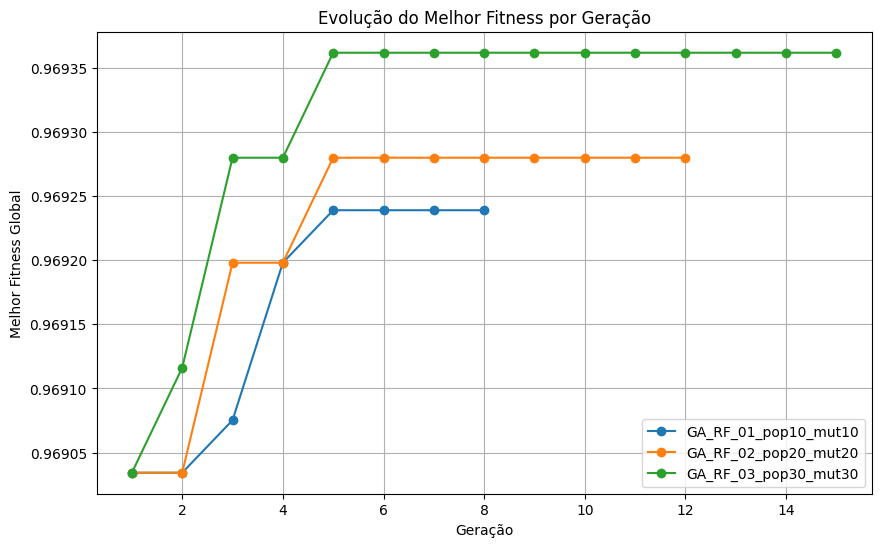

In [13]:
# ============================================================
# BLOCO 13 — Visualização da evolução do Algoritmo Genético
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for experimento in df_historico_ga["experimento"].unique():
    dados_exp = df_historico_ga[df_historico_ga["experimento"] == experimento]

    plt.plot(
        dados_exp["geracao"],
        dados_exp["melhor_fitness_global"],
        marker="o",
        label=experimento
    )

plt.title("Evolução do Melhor Fitness por Geração")
plt.xlabel("Geração")
plt.ylabel("Melhor Fitness Global")
plt.legend()
plt.grid(True)
plt.show()

# 7. Ajuste de limiar clínico

Nesta etapa é avaliado o impacto de diferentes limiares de decisão. Como o problema envolve apoio à triagem médica, o objetivo é analisar se a redução do limiar pode aumentar o recall da classe maligna e reduzir falsos negativos.

In [14]:
# ============================================================
# BLOCO 14 — Avaliação de limiares de decisão
# ============================================================

def avaliar_com_limiar(nome_modelo, modelo, X_test, y_test, threshold):
    """
    Avalia o modelo usando um limiar customizado.
    threshold menor tende a aumentar recall da classe maligna.
    """

    y_proba = modelo.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    roc_auc = roc_auc_score(y_test, y_proba)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

    especificidade = tn / (tn + fp) if (tn + fp) > 0 else 0

    return {
        "modelo": nome_modelo,
        "threshold": threshold,
        "accuracy": acc,
        "precision_maligno": precision,
        "recall_maligno": recall,
        "f1_maligno": f1,
        "roc_auc": roc_auc,
        "especificidade_benigno": especificidade,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }


thresholds = np.arange(0.10, 0.91, 0.05)

resultados_threshold = []

for threshold in thresholds:
    resultado = avaliar_com_limiar(
        "Random Forest Otimizado GA",
        rf_otimizado_ga,
        X_test,
        y_test,
        threshold
    )

    resultados_threshold.append(resultado)

df_thresholds = pd.DataFrame(resultados_threshold)

display(df_thresholds)

df_thresholds.to_csv(
    os.path.join(REPORTS_DIR, "analise_limiares_rf_otimizado_ga.csv"),
    index=False
)

print("Análise de limiares salva em:")
print(os.path.join(REPORTS_DIR, "analise_limiares_rf_otimizado_ga.csv"))

,modelo,threshold,accuracy,precision_maligno,recall_maligno,f1_maligno,roc_auc,especificidade_benigno,tn,fp,fn,tp
0,Random Forest Otimizado GA,0.10,0.877193,0.750000,1.000000,0.857143,0.997024,0.805556,58,14,0,42
1,Random Forest Otimizado GA,0.15,0.938596,0.857143,1.000000,0.923077,0.997024,0.902778,65,7,0,42
2,Random Forest Otimizado GA,0.20,0.947368,0.875000,1.000000,0.933333,0.997024,0.916667,66,6,0,42
3,Random Forest Otimizado GA,0.25,0.973684,0.953488,0.976190,0.964706,0.997024,0.972222,70,2,1,41
4,Random Forest Otimizado GA,0.30,0.964912,0.952381,0.952381,0.952381,0.997024,0.972222,70,2,2,40
5,Random Forest Otimizado GA,0.35,0.964912,0.975000,0.928571,0.951220,0.997024,0.986111,71,1,3,39
6,Random Forest Otimizado GA,0.40,0.964912,0.975000,0.928571,0.951220,0.997024,0.986111,71,1,3,39
7,Random Forest Otimizado GA,0.45,0.973684,1.000000,0.928571,0.962963,0.997024,1.000000,72,0,3,39
8,Random Forest Otimizado GA,0.50,0.973684,1.000000,0.928571,0.962963,0.997024,1.000000,72,0,3,39
9,Random Forest Otimizado GA,0.55,0.964912,1.000000,0.904762,0.950000,0.997024,1.000000,72,0,4,38


Análise de limiares salva em:
/content/drive/MyDrive/tech_challenge_fase2/reports/analise_limiares_rf_otimizado_ga.csv


In [15]:
# ============================================================
# BLOCO 15 — Seleção do melhor limiar clínico
# ============================================================

df_thresholds_ordenado = df_thresholds.sort_values(
    by=[
        "fn",
        "recall_maligno",
        "f1_maligno",
        "especificidade_benigno",
        "accuracy"
    ],
    ascending=[
        True,
        False,
        False,
        False,
        False
    ]
)

melhor_limiar_clinico = df_thresholds_ordenado.iloc[0]

print("Melhor limiar clínico encontrado:")
display(pd.DataFrame([melhor_limiar_clinico]))

melhor_threshold = melhor_limiar_clinico["threshold"]

print("Threshold escolhido:", melhor_threshold)
print("Falsos negativos:", int(melhor_limiar_clinico["fn"]))
print("Recall maligno:", round(melhor_limiar_clinico["recall_maligno"], 4))
print("Especificidade benigno:", round(melhor_limiar_clinico["especificidade_benigno"], 4))

Melhor limiar clínico encontrado:


,modelo,threshold,accuracy,precision_maligno,recall_maligno,f1_maligno,roc_auc,especificidade_benigno,tn,fp,fn,tp
2,Random Forest Otimizado GA,0.2,0.947368,0.875,1.0,0.933333,0.997024,0.916667,66,6,0,42


Threshold escolhido: 0.20000000000000004
Falsos negativos: 0
Recall maligno: 1.0
Especificidade benigno: 0.9167


In [16]:
# ============================================================
# BLOCO 16 — Comparativo final incluindo limiar clínico
# ============================================================

resultado_rf_otimizado_limiar = avaliar_com_limiar(
    "Random Forest Otimizado GA com Limiar Clínico",
    rf_otimizado_ga,
    X_test,
    y_test,
    melhor_threshold
)

resultado_rf_otimizado_limiar["tempo_treino_segundos"] = tempo_rf_otimizado
resultado_rf_otimizado_limiar["experimento_origem"] = melhor_experimento_nome
resultado_rf_otimizado_limiar["hiperparametros"] = str(melhores_params_rf)

df_resultado_rf_otimizado_limiar = pd.DataFrame([resultado_rf_otimizado_limiar])

df_comparativo_final_com_limiar = pd.concat(
    [
        df_resultados_baseline[df_resultados_baseline["modelo"] == "Random Forest Original"],
        df_resultado_rf_otimizado,
        df_resultado_rf_otimizado_limiar
    ],
    ignore_index=True
)

display(df_comparativo_final_com_limiar)

df_comparativo_final_com_limiar.to_csv(
    os.path.join(REPORTS_DIR, "comparativo_final_rf_original_ga_limiar.csv"),
    index=False
)

print("Comparativo final salvo em:")
print(os.path.join(REPORTS_DIR, "comparativo_final_rf_original_ga_limiar.csv"))

,modelo,accuracy,precision_maligno,recall_maligno,f1_maligno,roc_auc,especificidade_benigno,tn,fp,fn,tp,tempo_treino_segundos,experimento_origem,hiperparametros,threshold
0,Random Forest Original,0.973684,1.000,0.928571,0.962963,0.996528,1.000000,72,0,3,39,0.184747,NaN,NaN,NaN
1,Random Forest Otimizado com Algoritmo Genético,0.973684,1.000,0.928571,0.962963,0.997024,1.000000,72,0,3,39,0.474926,GA_RF_03_pop30_mut30,"{'n_estimators': 300, 'max_depth': None, 'min_...",NaN
2,Random Forest Otimizado GA com Limiar Clínico,0.947368,0.875,1.000000,0.933333,0.997024,0.916667,66,6,0,42,0.474926,GA_RF_03_pop30_mut30,"{'n_estimators': 300, 'max_depth': None, 'min_...",0.2


Comparativo final salvo em:
/content/drive/MyDrive/tech_challenge_fase2/reports/comparativo_final_rf_original_ga_limiar.csv


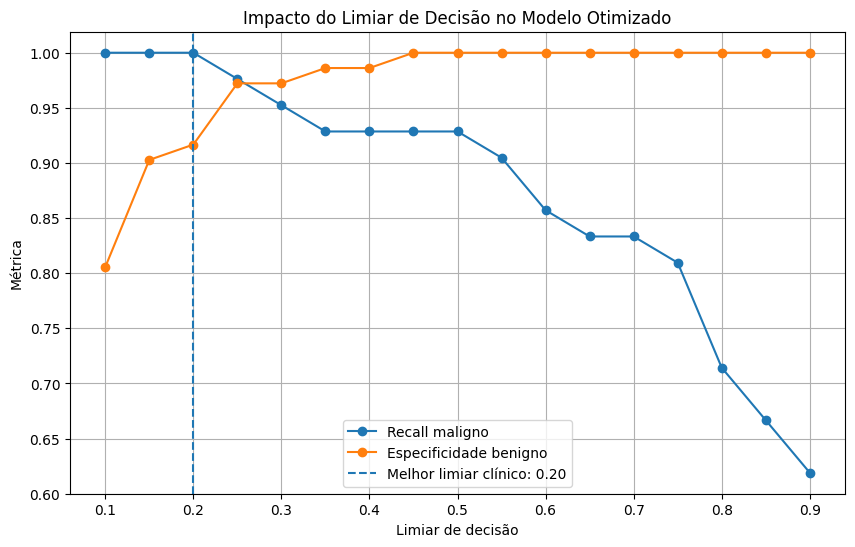

In [17]:
# ============================================================
# BLOCO 17 — Gráfico Recall x Especificidade por limiar
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    df_thresholds["threshold"],
    df_thresholds["recall_maligno"],
    marker="o",
    label="Recall maligno"
)

plt.plot(
    df_thresholds["threshold"],
    df_thresholds["especificidade_benigno"],
    marker="o",
    label="Especificidade benigno"
)

plt.axvline(
    melhor_threshold,
    linestyle="--",
    label=f"Melhor limiar clínico: {melhor_threshold:.2f}"
)

plt.title("Impacto do Limiar de Decisão no Modelo Otimizado")
plt.xlabel("Limiar de decisão")
plt.ylabel("Métrica")
plt.legend()
plt.grid(True)
plt.show()

# 8. Aprimoramento do Algoritmo Genético: Hotstart e Mutação Adaptativa

Nesta etapa é implementado um experimento adicional com hotstart e mutação adaptativa. O hotstart inicializa parte da população com soluções previamente conhecidas, enquanto a mutação adaptativa aumenta a exploração do espaço de busca em situações de estagnação.

In [18]:
# ============================================================
# BLOCO 18 — Funções auxiliares: hotstart, diversidade e entropia
# ============================================================

from collections import Counter
import math

def individuo_para_chave(individuo):
    """
    Converte um indivíduo em uma chave imutável para medir soluções únicas.
    """
    return tuple(sorted(individuo.items()))


def validar_individuo(individuo, search_space):
    """
    Garante que todos os genes do indivíduo existem no espaço de busca.
    """
    for gene, valor in individuo.items():
        if gene not in search_space:
            return False
        if valor not in search_space[gene]:
            return False
    return True


def criar_populacao_hotstart(search_space, tamanho_populacao, individuos_hotstart=None):
    """
    Cria população inicial com hotstart:
    - inclui indivíduos conhecidos/promissores;
    - completa o restante com indivíduos aleatórios;
    - evita duplicatas sempre que possível.
    """
    populacao = []
    chaves = set()

    if individuos_hotstart is not None:
        for individuo in individuos_hotstart:
            if validar_individuo(individuo, search_space):
                chave = individuo_para_chave(individuo)
                if chave not in chaves:
                    populacao.append(individuo.copy())
                    chaves.add(chave)

    while len(populacao) < tamanho_populacao:
        individuo = criar_individuo(search_space)
        chave = individuo_para_chave(individuo)

        if chave not in chaves:
            populacao.append(individuo)
            chaves.add(chave)

    return populacao


def calcular_entropia_genetica(populacao, search_space):
    """
    Calcula uma entropia média normalizada por gene.
    Quanto maior, maior a diversidade genética.
    """
    entropias = []

    for gene, valores_possiveis in search_space.items():
        alelos = [individuo[gene] for individuo in populacao]
        contagem = Counter(alelos)
        total = len(alelos)

        entropia = 0

        for qtd in contagem.values():
            p = qtd / total
            entropia -= p * math.log2(p)

        max_entropia = math.log2(len(valores_possiveis)) if len(valores_possiveis) > 1 else 1
        entropia_normalizada = entropia / max_entropia if max_entropia > 0 else 0

        entropias.append(entropia_normalizada)

    return np.mean(entropias)


def calcular_diversidade_populacao(populacao, search_space):
    """
    Calcula quantidade de indivíduos únicos e entropia genética.
    """
    chaves = [individuo_para_chave(individuo) for individuo in populacao]
    qtd_unicos = len(set(chaves))
    taxa_unicos = qtd_unicos / len(populacao)
    entropia = calcular_entropia_genetica(populacao, search_space)

    return {
        "qtd_individuos_unicos": qtd_unicos,
        "taxa_individuos_unicos": taxa_unicos,
        "entropia_genetica": entropia
    }

print("Funções auxiliares criadas com sucesso.")

Funções auxiliares criadas com sucesso.


In [19]:
# ============================================================
# BLOCO 19 — GA com hotstart, mutação adaptativa e logging avançado
# ============================================================

def executar_ga_rf_hotstart_adaptativo(
    nome_experimento,
    search_space,
    tamanho_populacao,
    numero_geracoes,
    taxa_mutacao_inicial,
    taxa_crossover,
    X_train_fit,
    y_train_fit,
    X_val,
    y_val,
    individuos_hotstart=None,
    paciencia_estagnacao=3,
    incremento_mutacao=0.05,
    reducao_mutacao=0.02,
    taxa_mutacao_min=0.05,
    taxa_mutacao_max=0.50
):
    """
    Executa Algoritmo Genético para Random Forest com:
    - hotstart na população inicial;
    - mutação adaptativa;
    - monitoramento de convergência;
    - monitoramento de diversidade genética.
    """

    print(f"\n==============================")
    print(f"Iniciando experimento: {nome_experimento}")
    print(f"População: {tamanho_populacao}")
    print(f"Gerações: {numero_geracoes}")
    print(f"Mutação inicial: {taxa_mutacao_inicial}")
    print(f"Crossover: {taxa_crossover}")
    print(f"Hotstart: {'Sim' if individuos_hotstart else 'Não'}")
    print(f"==============================")

    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)

    populacao = criar_populacao_hotstart(
        search_space=search_space,
        tamanho_populacao=tamanho_populacao,
        individuos_hotstart=individuos_hotstart
    )

    historico = []
    melhor_global = None
    melhor_fitness_anterior = -np.inf
    geracoes_sem_melhora = 0
    taxa_mutacao_atual = taxa_mutacao_inicial

    inicio_experimento = time.time()

    for geracao in range(1, numero_geracoes + 1):

        inicio_geracao = time.time()
        populacao_avaliada = []

        for individuo in populacao:
            fit, metricas = fitness_rf(
                individuo,
                X_train_fit,
                y_train_fit,
                X_val,
                y_val
            )

            populacao_avaliada.append({
                "individuo": individuo,
                "fitness": fit,
                "metricas": metricas
            })

        populacao_avaliada = sorted(
            populacao_avaliada,
            key=lambda x: x["fitness"],
            reverse=True
        )

        melhor_geracao = populacao_avaliada[0]

        fitness_todos = [item["fitness"] for item in populacao_avaliada]
        fitness_medio = np.mean(fitness_todos)
        fitness_std = np.std(fitness_todos)

        diversidade = calcular_diversidade_populacao(
            populacao=populacao,
            search_space=search_space
        )

        houve_melhora = melhor_geracao["fitness"] > melhor_fitness_anterior + 1e-6

        if melhor_global is None or melhor_geracao["fitness"] > melhor_global["fitness"]:
            melhor_global = melhor_geracao

        if houve_melhora:
            geracoes_sem_melhora = 0
            melhor_fitness_anterior = melhor_geracao["fitness"]

            taxa_mutacao_atual = max(
                taxa_mutacao_min,
                taxa_mutacao_atual - reducao_mutacao
            )
        else:
            geracoes_sem_melhora += 1

            if geracoes_sem_melhora >= paciencia_estagnacao:
                taxa_mutacao_atual = min(
                    taxa_mutacao_max,
                    taxa_mutacao_atual + incremento_mutacao
                )

        tempo_geracao = time.time() - inicio_geracao

        registro = {
            "experimento": nome_experimento,
            "geracao": geracao,
            "melhor_fitness_geracao": melhor_geracao["fitness"],
            "melhor_fitness_global": melhor_global["fitness"],
            "fitness_medio": fitness_medio,
            "fitness_desvio_padrao": fitness_std,
            "taxa_mutacao_geracao": taxa_mutacao_atual,
            "geracoes_sem_melhora": geracoes_sem_melhora,
            "tempo_geracao_segundos": tempo_geracao,
            "qtd_individuos_unicos": diversidade["qtd_individuos_unicos"],
            "taxa_individuos_unicos": diversidade["taxa_individuos_unicos"],
            "entropia_genetica": diversidade["entropia_genetica"],
            "accuracy": melhor_geracao["metricas"]["accuracy"],
            "recall_maligno": melhor_geracao["metricas"]["recall_maligno"],
            "f1_maligno": melhor_geracao["metricas"]["f1_maligno"],
            "roc_auc": melhor_geracao["metricas"]["roc_auc"],
            "especificidade_benigno": melhor_geracao["metricas"]["especificidade_benigno"],
            "tn": melhor_geracao["metricas"]["tn"],
            "fp": melhor_geracao["metricas"]["fp"],
            "fn": melhor_geracao["metricas"]["fn"],
            "tp": melhor_geracao["metricas"]["tp"],
            "hiperparametros": str(melhor_geracao["individuo"])
        }

        historico.append(registro)

        print(
            f"Geração {geracao:02d} | "
            f"Fit: {melhor_geracao['fitness']:.4f} | "
            f"Médio: {fitness_medio:.4f} | "
            f"Std: {fitness_std:.4f} | "
            f"Recall: {melhor_geracao['metricas']['recall_maligno']:.4f} | "
            f"F1: {melhor_geracao['metricas']['f1_maligno']:.4f} | "
            f"ROC AUC: {melhor_geracao['metricas']['roc_auc']:.4f} | "
            f"Mut: {taxa_mutacao_atual:.2f} | "
            f"Únicos: {diversidade['qtd_individuos_unicos']}/{tamanho_populacao}"
        )

        # Elitismo: mantém os 2 melhores indivíduos
        nova_populacao = [
            populacao_avaliada[0]["individuo"],
            populacao_avaliada[1]["individuo"]
        ]

        while len(nova_populacao) < tamanho_populacao:
            pai1 = selecao_torneio(populacao_avaliada)
            pai2 = selecao_torneio(populacao_avaliada)

            filho1, filho2 = crossover_uniforme(
                pai1,
                pai2,
                taxa_crossover
            )

            filho1 = mutacao(
                filho1,
                search_space,
                taxa_mutacao_atual
            )

            filho2 = mutacao(
                filho2,
                search_space,
                taxa_mutacao_atual
            )

            nova_populacao.append(filho1)

            if len(nova_populacao) < tamanho_populacao:
                nova_populacao.append(filho2)

        populacao = nova_populacao

    tempo_total = time.time() - inicio_experimento

    print("\nMelhor indivíduo encontrado:")
    print(melhor_global["individuo"])
    print("Melhor fitness:", round(melhor_global["fitness"], 4))
    print("Tempo total:", round(tempo_total, 2), "segundos")

    df_historico = pd.DataFrame(historico)

    return melhor_global, df_historico, tempo_total

print("Função do GA aprimorado criada com sucesso.")

Função do GA aprimorado criada com sucesso.


In [20]:
# ============================================================
# BLOCO 20 — Experimento GA_RF_04 com hotstart e mutação adaptativa
# ============================================================

rf_original_params = {
    "n_estimators": 100,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "max_features": "sqrt",
    "class_weight": "balanced"
}

# melhores_params_rf foi criado no Bloco 11.
# Caso não exista, usamos o melhor resultado que você já encontrou.
try:
    melhores_params_rf
except NameError:
    melhores_params_rf = {
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_features": "log2",
        "class_weight": "balanced"
    }

individuos_hotstart = [
    rf_original_params,
    melhores_params_rf
]

melhor_hotstart, df_historico_hotstart, tempo_hotstart = executar_ga_rf_hotstart_adaptativo(
    nome_experimento="GA_RF_04_hotstart_mutacao_adaptativa",
    search_space=search_space_rf,
    tamanho_populacao=30,
    numero_geracoes=15,
    taxa_mutacao_inicial=0.20,
    taxa_crossover=0.85,
    X_train_fit=X_ga_train,
    y_train_fit=y_ga_train,
    X_val=X_ga_val,
    y_val=y_ga_val,
    individuos_hotstart=individuos_hotstart,
    paciencia_estagnacao=3,
    incremento_mutacao=0.05,
    reducao_mutacao=0.02,
    taxa_mutacao_min=0.05,
    taxa_mutacao_max=0.50
)

df_historico_hotstart.to_csv(
    os.path.join(REPORTS_DIR, "historico_ga_rf_04_hotstart_adaptativo.csv"),
    index=False
)

print("Histórico salvo em:")
print(os.path.join(REPORTS_DIR, "historico_ga_rf_04_hotstart_adaptativo.csv"))

display(df_historico_hotstart.tail())


Iniciando experimento: GA_RF_04_hotstart_mutacao_adaptativa
População: 30
Gerações: 15
Mutação inicial: 0.2
Crossover: 0.85
Hotstart: Sim
Geração 01 | Fit: 0.9694 | Médio: 0.9636 | Std: 0.0049 | Recall: 0.9535 | F1: 0.9647 | ROC AUC: 0.9928 | Mut: 0.18 | Únicos: 30/30
Geração 02 | Fit: 0.9694 | Médio: 0.9659 | Std: 0.0047 | Recall: 0.9535 | F1: 0.9647 | ROC AUC: 0.9928 | Mut: 0.18 | Únicos: 29/30
Geração 03 | Fit: 0.9694 | Médio: 0.9677 | Std: 0.0031 | Recall: 0.9535 | F1: 0.9647 | ROC AUC: 0.9928 | Mut: 0.18 | Únicos: 27/30
Geração 04 | Fit: 0.9694 | Médio: 0.9675 | Std: 0.0032 | Recall: 0.9535 | F1: 0.9647 | ROC AUC: 0.9928 | Mut: 0.23 | Únicos: 26/30
Geração 05 | Fit: 0.9694 | Médio: 0.9663 | Std: 0.0036 | Recall: 0.9535 | F1: 0.9647 | ROC AUC: 0.9928 | Mut: 0.28 | Únicos: 27/30
Geração 06 | Fit: 0.9694 | Médio: 0.9667 | Std: 0.0045 | Recall: 0.9535 | F1: 0.9647 | ROC AUC: 0.9928 | Mut: 0.33 | Únicos: 28/30
Geração 07 | Fit: 0.9694 | Médio: 0.9652 | Std: 0.0048 | Recall: 0.9535 | F

,experimento,geracao,melhor_fitness_geracao,melhor_fitness_global,fitness_medio,fitness_desvio_padrao,taxa_mutacao_geracao,geracoes_sem_melhora,tempo_geracao_segundos,qtd_individuos_unicos,...,accuracy,recall_maligno,f1_maligno,roc_auc,especificidade_benigno,tn,fp,fn,tp,hiperparametros
10,GA_RF_04_hotstart_mutacao_adaptativa,11,0.969362,0.969362,0.966144,0.004213,0.5,10,12.607904,29,...,0.973684,0.953488,0.964706,0.992794,0.985915,70,1,2,41,"{'n_estimators': 300, 'max_depth': None, 'min_..."
11,GA_RF_04_hotstart_mutacao_adaptativa,12,0.969362,0.969362,0.965722,0.005023,0.5,11,14.572062,27,...,0.973684,0.953488,0.964706,0.992794,0.985915,70,1,2,41,"{'n_estimators': 300, 'max_depth': None, 'min_..."
12,GA_RF_04_hotstart_mutacao_adaptativa,13,0.969362,0.969362,0.966561,0.004310,0.5,12,14.134347,25,...,0.973684,0.953488,0.964706,0.992794,0.985915,70,1,2,41,"{'n_estimators': 300, 'max_depth': None, 'min_..."
13,GA_RF_04_hotstart_mutacao_adaptativa,14,0.969362,0.969362,0.965381,0.004297,0.5,13,15.607124,29,...,0.973684,0.953488,0.964706,0.992794,0.985915,70,1,2,41,"{'n_estimators': 300, 'max_depth': None, 'min_..."
14,GA_RF_04_hotstart_mutacao_adaptativa,15,0.969362,0.969362,0.964582,0.004935,0.5,14,13.382837,29,...,0.973684,0.953488,0.964706,0.992794,0.985915,70,1,2,41,"{'n_estimators': 300, 'max_depth': None, 'min_..."


In [21]:
# ============================================================
# BLOCO 21 — Treinamento final do modelo GA_RF_04
# ============================================================

melhores_params_hotstart = melhor_hotstart["individuo"]

print("Melhores hiperparâmetros do GA_RF_04:")
print(melhores_params_hotstart)

rf_otimizado_hotstart = RandomForestClassifier(
    n_estimators=melhores_params_hotstart["n_estimators"],
    max_depth=melhores_params_hotstart["max_depth"],
    min_samples_split=melhores_params_hotstart["min_samples_split"],
    min_samples_leaf=melhores_params_hotstart["min_samples_leaf"],
    max_features=melhores_params_hotstart["max_features"],
    class_weight=melhores_params_hotstart["class_weight"],
    random_state=RANDOM_STATE,
    n_jobs=-1
)

inicio = time.time()

rf_otimizado_hotstart.fit(X_train, y_train)

tempo_rf_hotstart = time.time() - inicio

resultado_rf_hotstart = avaliar_modelo(
    "Random Forest GA Hotstart Adaptativo",
    rf_otimizado_hotstart,
    X_test,
    y_test
)

resultado_rf_hotstart["tempo_treino_segundos"] = tempo_rf_hotstart
resultado_rf_hotstart["experimento_origem"] = "GA_RF_04_hotstart_mutacao_adaptativa"
resultado_rf_hotstart["hiperparametros"] = str(melhores_params_hotstart)

df_resultado_rf_hotstart = pd.DataFrame([resultado_rf_hotstart])

display(df_resultado_rf_hotstart)

df_resultado_rf_hotstart.to_csv(
    os.path.join(REPORTS_DIR, "metricas_rf_ga_04_hotstart_adaptativo.csv"),
    index=False
)

print("Métricas salvas em:")
print(os.path.join(REPORTS_DIR, "metricas_rf_ga_04_hotstart_adaptativo.csv"))

Melhores hiperparâmetros do GA_RF_04:
{'n_estimators': 300, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'class_weight': 'balanced'}

===== Random Forest GA Hotstart Adaptativo =====
Accuracy: 0.9737
Precision maligno: 1.0
Recall maligno: 0.9286
F1 maligno: 0.963
ROC AUC: 0.997
Especificidade benigno: 1.0

Matriz de confusão:
[[72  0]
 [ 3 39]]

Relatório de classificação:
              precision    recall  f1-score   support

     Benigno       0.96      1.00      0.98        72
     Maligno       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



,modelo,accuracy,precision_maligno,recall_maligno,f1_maligno,roc_auc,especificidade_benigno,tn,fp,fn,tp,tempo_treino_segundos,experimento_origem,hiperparametros
0,Random Forest GA Hotstart Adaptativo,0.973684,1.0,0.928571,0.962963,0.997024,1.0,72,0,3,39,0.485725,GA_RF_04_hotstart_mutacao_adaptativa,"{'n_estimators': 300, 'max_depth': None, 'min_..."


Métricas salvas em:
/content/drive/MyDrive/tech_challenge_fase2/reports/metricas_rf_ga_04_hotstart_adaptativo.csv


In [22]:
# ============================================================
# BLOCO 22 — Avaliação do GA_RF_04 com limiar clínico de 0.20
# ============================================================

threshold_clinico = 0.20

resultado_rf_hotstart_limiar = avaliar_com_limiar(
    "Random Forest GA Hotstart Adaptativo com Limiar Clínico",
    rf_otimizado_hotstart,
    X_test,
    y_test,
    threshold_clinico
)

resultado_rf_hotstart_limiar["tempo_treino_segundos"] = tempo_rf_hotstart
resultado_rf_hotstart_limiar["experimento_origem"] = "GA_RF_04_hotstart_mutacao_adaptativa"
resultado_rf_hotstart_limiar["hiperparametros"] = str(melhores_params_hotstart)

df_resultado_rf_hotstart_limiar = pd.DataFrame([resultado_rf_hotstart_limiar])

display(df_resultado_rf_hotstart_limiar)

df_resultado_rf_hotstart_limiar.to_csv(
    os.path.join(REPORTS_DIR, "metricas_rf_ga_04_hotstart_adaptativo_limiar.csv"),
    index=False
)

print("Métricas com limiar clínico salvas em:")
print(os.path.join(REPORTS_DIR, "metricas_rf_ga_04_hotstart_adaptativo_limiar.csv"))

,modelo,threshold,accuracy,precision_maligno,recall_maligno,f1_maligno,roc_auc,especificidade_benigno,tn,fp,fn,tp,tempo_treino_segundos,experimento_origem,hiperparametros
0,Random Forest GA Hotstart Adaptativo com Limia...,0.2,0.947368,0.875,1.0,0.933333,0.997024,0.916667,66,6,0,42,0.485725,GA_RF_04_hotstart_mutacao_adaptativa,"{'n_estimators': 300, 'max_depth': None, 'min_..."


Métricas com limiar clínico salvas em:
/content/drive/MyDrive/tech_challenge_fase2/reports/metricas_rf_ga_04_hotstart_adaptativo_limiar.csv


In [23]:
# ============================================================
# BLOCO 23 — Comparativo final completo
# ============================================================

df_comparativo_final_aprimorado = pd.concat(
    [
        df_resultados_baseline[df_resultados_baseline["modelo"] == "Random Forest Original"],
        df_resultado_rf_otimizado,
        df_resultado_rf_otimizado_limiar,
        df_resultado_rf_hotstart,
        df_resultado_rf_hotstart_limiar
    ],
    ignore_index=True
)

display(df_comparativo_final_aprimorado)

df_comparativo_final_aprimorado.to_csv(
    os.path.join(REPORTS_DIR, "comparativo_final_rf_ga_hotstart_limiar.csv"),
    index=False
)

print("Comparativo final aprimorado salvo em:")
print(os.path.join(REPORTS_DIR, "comparativo_final_rf_ga_hotstart_limiar.csv"))

,modelo,accuracy,precision_maligno,recall_maligno,f1_maligno,roc_auc,especificidade_benigno,tn,fp,fn,tp,tempo_treino_segundos,experimento_origem,hiperparametros,threshold
0,Random Forest Original,0.973684,1.000,0.928571,0.962963,0.996528,1.000000,72,0,3,39,0.184747,NaN,NaN,NaN
1,Random Forest Otimizado com Algoritmo Genético,0.973684,1.000,0.928571,0.962963,0.997024,1.000000,72,0,3,39,0.474926,GA_RF_03_pop30_mut30,"{'n_estimators': 300, 'max_depth': None, 'min_...",NaN
2,Random Forest Otimizado GA com Limiar Clínico,0.947368,0.875,1.000000,0.933333,0.997024,0.916667,66,6,0,42,0.474926,GA_RF_03_pop30_mut30,"{'n_estimators': 300, 'max_depth': None, 'min_...",0.2
3,Random Forest GA Hotstart Adaptativo,0.973684,1.000,0.928571,0.962963,0.997024,1.000000,72,0,3,39,0.485725,GA_RF_04_hotstart_mutacao_adaptativa,"{'n_estimators': 300, 'max_depth': None, 'min_...",NaN
4,Random Forest GA Hotstart Adaptativo com Limia...,0.947368,0.875,1.000000,0.933333,0.997024,0.916667,66,6,0,42,0.485725,GA_RF_04_hotstart_mutacao_adaptativa,"{'n_estimators': 300, 'max_depth': None, 'min_...",0.2


Comparativo final aprimorado salvo em:
/content/drive/MyDrive/tech_challenge_fase2/reports/comparativo_final_rf_ga_hotstart_limiar.csv


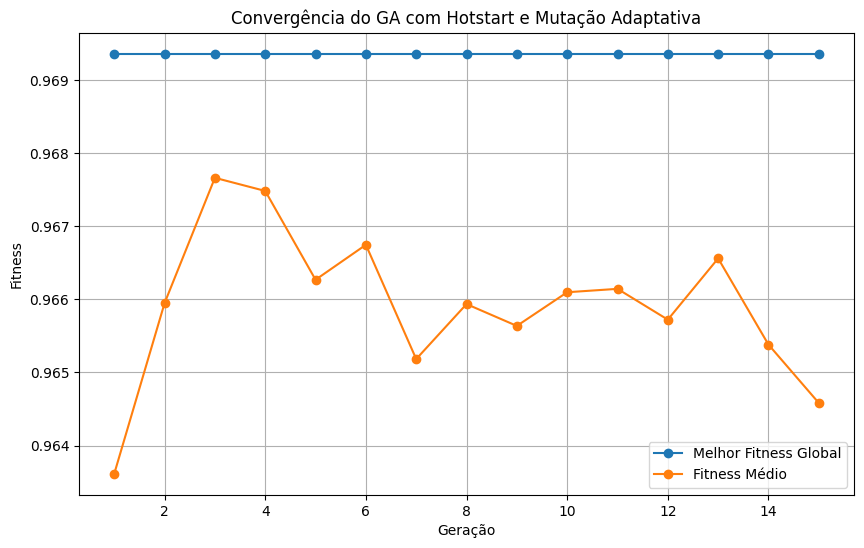

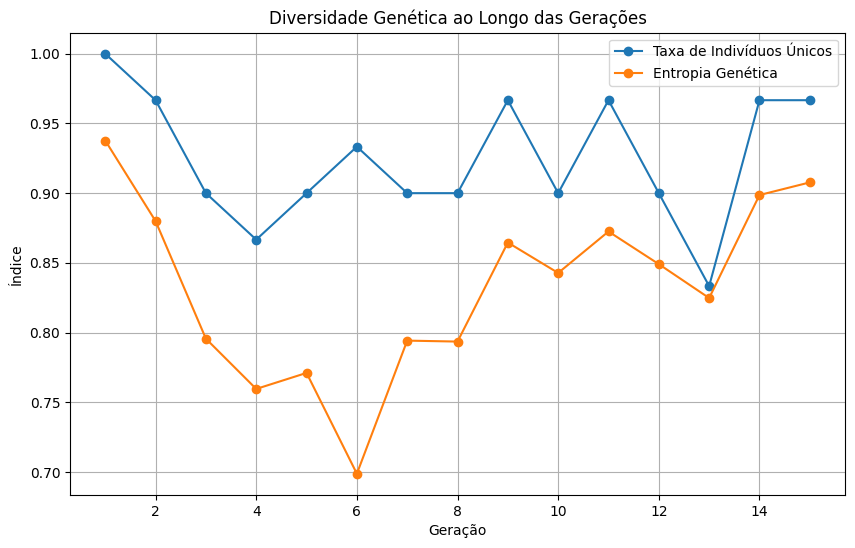

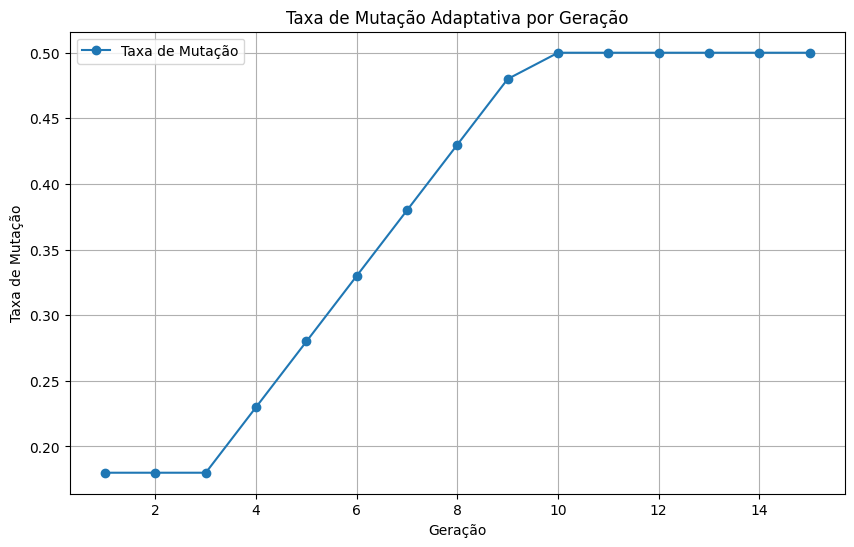

In [24]:
# ============================================================
# BLOCO 24 — Visualizações do GA aprimorado
# ============================================================

import matplotlib.pyplot as plt

# Gráfico 1 — Fitness global
plt.figure(figsize=(10, 6))
plt.plot(
    df_historico_hotstart["geracao"],
    df_historico_hotstart["melhor_fitness_global"],
    marker="o",
    label="Melhor Fitness Global"
)
plt.plot(
    df_historico_hotstart["geracao"],
    df_historico_hotstart["fitness_medio"],
    marker="o",
    label="Fitness Médio"
)
plt.title("Convergência do GA com Hotstart e Mutação Adaptativa")
plt.xlabel("Geração")
plt.ylabel("Fitness")
plt.legend()
plt.grid(True)
plt.show()


# Gráfico 2 — Diversidade genética
plt.figure(figsize=(10, 6))
plt.plot(
    df_historico_hotstart["geracao"],
    df_historico_hotstart["taxa_individuos_unicos"],
    marker="o",
    label="Taxa de Indivíduos Únicos"
)
plt.plot(
    df_historico_hotstart["geracao"],
    df_historico_hotstart["entropia_genetica"],
    marker="o",
    label="Entropia Genética"
)
plt.title("Diversidade Genética ao Longo das Gerações")
plt.xlabel("Geração")
plt.ylabel("Índice")
plt.legend()
plt.grid(True)
plt.show()


# Gráfico 3 — Mutação adaptativa
plt.figure(figsize=(10, 6))
plt.plot(
    df_historico_hotstart["geracao"],
    df_historico_hotstart["taxa_mutacao_geracao"],
    marker="o",
    label="Taxa de Mutação"
)
plt.title("Taxa de Mutação Adaptativa por Geração")
plt.xlabel("Geração")
plt.ylabel("Taxa de Mutação")
plt.legend()
plt.grid(True)
plt.show()

# 9. Integração com LLM para interpretação dos resultados

Nesta etapa é utilizada uma LLM para transformar os resultados estatísticos dos modelos em uma interpretação em linguagem natural, voltada para médicos e gestores hospitalares. A resposta gerada é revisada para garantir coerência técnica e segurança no contexto médico.

In [25]:
# ============================================================
# BLOCO 25 — Instalação das bibliotecas para LLM
# ============================================================

!pip install -q langchain langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 1.7 MB/s eta 0:00:00


In [26]:
# ============================================================
# BLOCO 26 — Configuração da GROQ_API_KEY
# ============================================================

import os
from getpass import getpass

os.environ["GROQ_API_KEY"] = getpass("Cole sua GROQ_API_KEY aqui: ")

print("Chave configurada com sucesso.")

Cole sua GROQ_API_KEY aqui: ··········
Chave configurada com sucesso.


In [27]:
# ============================================================
# BLOCO 27 — Preparação automática do resumo dos modelos
# ============================================================

# Garante que estamos usando a tabela final aprimorada
df_llm = df_comparativo_final_aprimorado.copy()

# Selecionar linhas principais
linha_original = df_llm[df_llm["modelo"] == "Random Forest Original"].iloc[0]
linha_ga = df_llm[df_llm["modelo"] == "Random Forest Otimizado com Algoritmo Genético"].iloc[0]
linha_ga_limiar = df_llm[df_llm["modelo"] == "Random Forest Otimizado GA com Limiar Clínico"].iloc[0]
linha_hotstart = df_llm[df_llm["modelo"] == "Random Forest GA Hotstart Adaptativo"].iloc[0]
linha_hotstart_limiar = df_llm[
    df_llm["modelo"].str.contains("Hotstart Adaptativo com Limiar", case=False, na=False)
].iloc[0]

resumo_resultados = f"""
Resultados finais do projeto:

1. Modelo Original — Random Forest:
- Accuracy: {linha_original["accuracy"]:.4f}
- Precision maligno: {linha_original["precision_maligno"]:.4f}
- Recall maligno: {linha_original["recall_maligno"]:.4f}
- F1 maligno: {linha_original["f1_maligno"]:.4f}
- ROC AUC: {linha_original["roc_auc"]:.4f}
- Especificidade benigno: {linha_original["especificidade_benigno"]:.4f}
- Verdadeiros negativos: {int(linha_original["tn"])}
- Falsos positivos: {int(linha_original["fp"])}
- Falsos negativos: {int(linha_original["fn"])}
- Verdadeiros positivos: {int(linha_original["tp"])}

2. Modelo Otimizado com Algoritmo Genético:
- Accuracy: {linha_ga["accuracy"]:.4f}
- Precision maligno: {linha_ga["precision_maligno"]:.4f}
- Recall maligno: {linha_ga["recall_maligno"]:.4f}
- F1 maligno: {linha_ga["f1_maligno"]:.4f}
- ROC AUC: {linha_ga["roc_auc"]:.4f}
- Especificidade benigno: {linha_ga["especificidade_benigno"]:.4f}
- Verdadeiros negativos: {int(linha_ga["tn"])}
- Falsos positivos: {int(linha_ga["fp"])}
- Falsos negativos: {int(linha_ga["fn"])}
- Verdadeiros positivos: {int(linha_ga["tp"])}

3. Modelo Otimizado com Algoritmo Genético e Limiar Clínico 0.20:
- Accuracy: {linha_ga_limiar["accuracy"]:.4f}
- Precision maligno: {linha_ga_limiar["precision_maligno"]:.4f}
- Recall maligno: {linha_ga_limiar["recall_maligno"]:.4f}
- F1 maligno: {linha_ga_limiar["f1_maligno"]:.4f}
- ROC AUC: {linha_ga_limiar["roc_auc"]:.4f}
- Especificidade benigno: {linha_ga_limiar["especificidade_benigno"]:.4f}
- Verdadeiros negativos: {int(linha_ga_limiar["tn"])}
- Falsos positivos: {int(linha_ga_limiar["fp"])}
- Falsos negativos: {int(linha_ga_limiar["fn"])}
- Verdadeiros positivos: {int(linha_ga_limiar["tp"])}

4. Modelo GA com Hotstart e Mutação Adaptativa:
- Accuracy: {linha_hotstart["accuracy"]:.4f}
- Precision maligno: {linha_hotstart["precision_maligno"]:.4f}
- Recall maligno: {linha_hotstart["recall_maligno"]:.4f}
- F1 maligno: {linha_hotstart["f1_maligno"]:.4f}
- ROC AUC: {linha_hotstart["roc_auc"]:.4f}
- Especificidade benigno: {linha_hotstart["especificidade_benigno"]:.4f}
- Verdadeiros negativos: {int(linha_hotstart["tn"])}
- Falsos positivos: {int(linha_hotstart["fp"])}
- Falsos negativos: {int(linha_hotstart["fn"])}
- Verdadeiros positivos: {int(linha_hotstart["tp"])}

5. Modelo GA com Hotstart, Mutação Adaptativa e Limiar Clínico 0.20:
- Accuracy: {linha_hotstart_limiar["accuracy"]:.4f}
- Precision maligno: {linha_hotstart_limiar["precision_maligno"]:.4f}
- Recall maligno: {linha_hotstart_limiar["recall_maligno"]:.4f}
- F1 maligno: {linha_hotstart_limiar["f1_maligno"]:.4f}
- ROC AUC: {linha_hotstart_limiar["roc_auc"]:.4f}
- Especificidade benigno: {linha_hotstart_limiar["especificidade_benigno"]:.4f}
- Verdadeiros negativos: {int(linha_hotstart_limiar["tn"])}
- Falsos positivos: {int(linha_hotstart_limiar["fp"])}
- Falsos negativos: {int(linha_hotstart_limiar["fn"])}
- Verdadeiros positivos: {int(linha_hotstart_limiar["tp"])}
"""

print(resumo_resultados)


Resultados finais do projeto:

1. Modelo Original — Random Forest:
- Accuracy: 0.9737
- Precision maligno: 1.0000
- Recall maligno: 0.9286
- F1 maligno: 0.9630
- ROC AUC: 0.9965
- Especificidade benigno: 1.0000
- Verdadeiros negativos: 72
- Falsos positivos: 0
- Falsos negativos: 3
- Verdadeiros positivos: 39

2. Modelo Otimizado com Algoritmo Genético:
- Accuracy: 0.9737
- Precision maligno: 1.0000
- Recall maligno: 0.9286
- F1 maligno: 0.9630
- ROC AUC: 0.9970
- Especificidade benigno: 1.0000
- Verdadeiros negativos: 72
- Falsos positivos: 0
- Falsos negativos: 3
- Verdadeiros positivos: 39

3. Modelo Otimizado com Algoritmo Genético e Limiar Clínico 0.20:
- Accuracy: 0.9474
- Precision maligno: 0.8750
- Recall maligno: 1.0000
- F1 maligno: 0.9333
- ROC AUC: 0.9970
- Especificidade benigno: 0.9167
- Verdadeiros negativos: 66
- Falsos positivos: 6
- Falsos negativos: 0
- Verdadeiros positivos: 42

4. Modelo GA com Hotstart e Mutação Adaptativa:
- Accuracy: 0.9737
- Precision maligno:

In [28]:
# ============================================================
# BLOCO 28 — Prompt engineering para interpretação médica
# ============================================================

prompt_interpretacao_llm = f"""
Você é um assistente especializado em interpretar resultados de modelos de Machine Learning aplicados à triagem médica.

Contexto:
Foi desenvolvido um modelo de classificação para apoio ao diagnóstico de câncer de mama, classificando os casos como benigno ou maligno.

A solução compara:
1. Random Forest original;
2. Random Forest otimizado com Algoritmo Genético;
3. Random Forest otimizado com Algoritmo Genético e limiar clínico de 0.20;
4. Random Forest com Algoritmo Genético, hotstart e mutação adaptativa;
5. Random Forest com Algoritmo Genético, hotstart, mutação adaptativa e limiar clínico de 0.20.

Dados dos resultados:
{resumo_resultados}

Instruções obrigatórias:
- Responda em português do Brasil.
- Use linguagem técnica, mas compreensível para médicos e gestores hospitalares.
- Não afirme que o modelo substitui o médico.
- Não afirme que o modelo gera diagnóstico definitivo.
- Explique que o modelo serve como apoio à triagem e priorização de análise clínica.
- Destaque a importância de reduzir falsos negativos em contexto médico.
- Explique o trade-off do limiar clínico de 0.20: maior recall para maligno, porém mais falsos positivos.
- Explique que o Algoritmo Genético apresentou ganho discreto em ROC AUC e manteve estabilidade do desempenho.
- Explique que o hotstart e a mutação adaptativa melhoraram o monitoramento do processo evolutivo, mesmo sem alterar o resultado final no teste.

Estruture a resposta com os seguintes tópicos:
1. Resumo executivo.
2. Comparação entre modelo original e modelo otimizado.
3. Interpretação do limiar clínico de 0.20.
4. Interpretação do experimento com hotstart e mutação adaptativa.
5. Riscos e limitações.
6. Recomendação de uso.

Não invente informações clínicas além dos dados fornecidos.
"""

print(prompt_interpretacao_llm)


Você é um assistente especializado em interpretar resultados de modelos de Machine Learning aplicados à triagem médica.

Contexto:
Foi desenvolvido um modelo de classificação para apoio ao diagnóstico de câncer de mama, classificando os casos como benigno ou maligno.

A solução compara:
1. Random Forest original;
2. Random Forest otimizado com Algoritmo Genético;
3. Random Forest otimizado com Algoritmo Genético e limiar clínico de 0.20;
4. Random Forest com Algoritmo Genético, hotstart e mutação adaptativa;
5. Random Forest com Algoritmo Genético, hotstart, mutação adaptativa e limiar clínico de 0.20.

Dados dos resultados:

Resultados finais do projeto:

1. Modelo Original — Random Forest:
- Accuracy: 0.9737
- Precision maligno: 1.0000
- Recall maligno: 0.9286
- F1 maligno: 0.9630
- ROC AUC: 0.9965
- Especificidade benigno: 1.0000
- Verdadeiros negativos: 72
- Falsos positivos: 0
- Falsos negativos: 3
- Verdadeiros positivos: 39

2. Modelo Otimizado com Algoritmo Genético:
- Accurac

In [29]:
# ============================================================
# BLOCO 29 — Execução da LLM via Groq
# ============================================================

from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.2
)

resposta_llm = llm.invoke([
    HumanMessage(content=prompt_interpretacao_llm)
])

interpretacao_llm = resposta_llm.content

print(interpretacao_llm)

**1. Resumo Executivo**

O objetivo deste projeto foi desenvolver e comparar diferentes abordagens de otimização para um modelo de classificação de câncer de mama, visando melhorar a precisão e a eficácia na triagem e priorização de análise clínica. Os resultados mostram que as otimizações realizadas com Algoritmo Genético e outras técnicas apresentaram ganhos discretos em termos de desempenho, especialmente ao considerar a importância de reduzir falsos negativos em contextos médicos. O modelo serve como apoio à triagem e priorização de análise clínica, não substituindo o diagnóstico médico, mas auxiliando na identificação de casos que requerem atenção prioritária.

**2. Comparação entre Modelo Original e Modelo Otimizado**

A comparação entre o modelo original de Random Forest e as versões otimizadas com Algoritmo Genético mostra que as otimizações apresentaram ganhos discretos em termos de desempenho. O modelo otimizado com Algoritmo Genético manteve a mesma acurácia do modelo origin

# 10. Consolidação e salvamento dos arquivos

Nesta etapa são salvos os prompts, respostas da LLM, métricas, comparativos e arquivos finais do projeto. Também é realizado backup no Google Drive para preservar os resultados gerados no ambiente do Colab.

In [30]:
# ============================================================
# BLOCO 30 — Salvamento da interpretação da LLM
# ============================================================

import os

prompt_path = os.path.join(REPORTS_DIR, "prompt_interpretacao_llm.txt")
resposta_original_path = os.path.join(REPORTS_DIR, "interpretacao_resultados_llm_original.txt")
resposta_revisada_path = os.path.join(REPORTS_DIR, "interpretacao_resultados_llm_revisada.txt")

# Salvar prompt usado
with open(prompt_path, "w", encoding="utf-8") as f:
    f.write(prompt_interpretacao_llm)

# Salvar resposta original da LLM
with open(resposta_original_path, "w", encoding="utf-8") as f:
    f.write(interpretacao_llm)

# Cole aqui a versão revisada que vamos usar no relatório
interpretacao_llm_revisada = """
1. Resumo executivo

O projeto desenvolveu e comparou diferentes versões de um modelo de classificação para apoio à triagem de câncer de mama, utilizando Random Forest como modelo principal e Algoritmo Genético para otimização de hiperparâmetros.

O modelo original apresentou desempenho elevado, com acurácia de 97,37%, recall para a classe maligna de 92,86% e ROC AUC de 0.9965. Após a otimização via Algoritmo Genético, a acurácia, o recall e a matriz de confusão permaneceram equivalentes, mas houve uma pequena melhora no ROC AUC, passando para 0.9970.

A principal melhoria prática foi obtida com o ajuste do limiar de decisão para 0.20, que elevou o recall da classe maligna para 100%, eliminando os falsos negativos no conjunto de teste. Como contrapartida, houve aumento de falsos positivos e redução da acurácia para 94,74%.

O modelo deve ser interpretado como uma ferramenta de apoio à triagem e priorização clínica, não como um sistema de diagnóstico autônomo.

2. Comparação entre modelo original e modelo otimizado

O modelo Random Forest original apresentou desempenho robusto, com 72 verdadeiros negativos, 39 verdadeiros positivos, 0 falsos positivos e 3 falsos negativos.

O modelo otimizado com Algoritmo Genético manteve a mesma matriz de confusão do modelo original, também com 3 falsos negativos e 0 falsos positivos. A acurácia permaneceu em 97,37%, o recall maligno em 92,86% e o F1-score em 96,30%.

A diferença observada foi no ROC AUC, que aumentou de 0.9965 para 0.9970, indicando uma melhora discreta na capacidade probabilística de separação entre casos benignos e malignos.

3. Interpretação do limiar clínico de 0.20

A aplicação do limiar clínico de 0.20 alterou a estratégia de decisão do modelo. Em vez de classificar como maligno apenas casos com probabilidade igual ou superior a 0.50, o modelo passou a sinalizar como malignos os casos com probabilidade igual ou superior a 0.20.

Essa mudança aumentou a sensibilidade do modelo para casos malignos. O recall maligno passou de 92,86% para 100%, eliminando os falsos negativos no conjunto de teste.

Em contexto médico, essa decisão é defensável porque falsos negativos representam casos malignos classificados como benignos, o que pode atrasar a avaliação clínica. O custo dessa abordagem foi o aumento de falsos positivos, que passaram de 0 para 6, reduzindo a especificidade de 100% para 91,67%.

Assim, o limiar de 0.20 favorece uma abordagem mais conservadora para triagem, priorizando a identificação de possíveis casos malignos.

4. Interpretação do experimento com hotstart e mutação adaptativa

O experimento com hotstart e mutação adaptativa foi implementado para aprimorar o processo evolutivo do Algoritmo Genético.

O hotstart permitiu inicializar parte da população com configurações previamente conhecidas, incluindo o modelo baseline e a melhor configuração encontrada nos experimentos anteriores. A mutação adaptativa foi utilizada para aumentar a exploração do espaço de busca quando o algoritmo apresentou estagnação.

Embora essa abordagem não tenha alterado o desempenho final no conjunto de teste, ela fortaleceu a análise do Algoritmo Genético ao permitir monitorar métricas como fitness médio, desvio padrão do fitness, quantidade de indivíduos únicos, entropia genética, taxa de mutação por geração e tempo de execução.

Dessa forma, o experimento contribuiu para uma avaliação mais completa da convergência, diversidade e estabilidade do processo evolutivo.

5. Riscos e limitações

Apesar dos bons resultados, o modelo apresenta limitações importantes.

Primeiro, os resultados foram obtidos em um conjunto de dados específico e controlado, sendo necessária validação com bases externas antes de qualquer uso em ambiente clínico real.

Segundo, o ajuste do limiar de decisão envolve um trade-off: ao reduzir falsos negativos, o modelo aumenta falsos positivos. Isso pode gerar encaminhamentos adicionais para avaliação médica.

Terceiro, o modelo não considera informações clínicas complementares, histórico do paciente, exames de imagem, laudos médicos ou avaliação especializada.

Portanto, o sistema não deve ser utilizado como ferramenta de diagnóstico definitivo.

6. Recomendação de uso

A versão recomendada para triagem é o Random Forest otimizado com Algoritmo Genético e limiar clínico de 0.20, pois essa configuração eliminou os falsos negativos no conjunto de teste e atingiu recall maligno de 100%.

A recomendação é utilizar o modelo como apoio à priorização de casos que devem receber análise clínica mais detalhada. O resultado do modelo deve ser interpretado por profissionais de saúde e integrado a protocolos médicos, mantendo o diagnóstico final sob responsabilidade médica.
"""

# Salvar resposta revisada
with open(resposta_revisada_path, "w", encoding="utf-8") as f:
    f.write(interpretacao_llm_revisada)

print("Prompt salvo em:", prompt_path)
print("Resposta original da LLM salva em:", resposta_original_path)
print("Resposta revisada salva em:", resposta_revisada_path)

Prompt salvo em: /content/drive/MyDrive/tech_challenge_fase2/reports/prompt_interpretacao_llm.txt
Resposta original da LLM salva em: /content/drive/MyDrive/tech_challenge_fase2/reports/interpretacao_resultados_llm_original.txt
Resposta revisada salva em: /content/drive/MyDrive/tech_challenge_fase2/reports/interpretacao_resultados_llm_revisada.txt


In [31]:
# ============================================================
# BACKUP FINAL — Salvar projeto no Google Drive
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import shutil

ORIGEM = BASE_DIR
DESTINO = "/content/drive/MyDrive/tech_challenge_fase2_backup"

os.makedirs(DESTINO, exist_ok=True)

# Copiar todos os arquivos e pastas do projeto para o Drive
shutil.copytree(
    ORIGEM,
    DESTINO,
    dirs_exist_ok=True
)

print("Backup salvo em:", DESTINO)

# Criar ZIP do projeto também
zip_path = "/content/drive/MyDrive/tech_challenge_fase2_backup_zip"

shutil.make_archive(
    zip_path,
    'zip',
    ORIGEM
)

print("ZIP salvo em:", zip_path + ".zip")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Backup salvo em: /content/drive/MyDrive/tech_challenge_fase2_backup
ZIP salvo em: /content/drive/MyDrive/tech_challenge_fase2_backup_zip.zip


In [33]:
# ============================================================
# BLOCO 31 — Consolidar pasta final da entrega
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import shutil

# Usa o diretório principal já configurado no Bloco 1
ORIGEM = BASE_DIR

DESTINO_FINAL = "/content/drive/MyDrive/tech_challenge_fase2_entrega"

os.makedirs(DESTINO_FINAL, exist_ok=True)

# Copiar tudo do projeto atual para a pasta final da entrega
shutil.copytree(
    ORIGEM,
    DESTINO_FINAL,
    dirs_exist_ok=True
)

# Criar subpastas esperadas para organização da entrega
pastas = [
    "notebooks",
    "reports",
    "docs",
    "src",
    "tests"
]

for pasta in pastas:
    os.makedirs(os.path.join(DESTINO_FINAL, pasta), exist_ok=True)

print("Pasta final criada em:")
print(DESTINO_FINAL)

print("\nArquivos copiados de:")
print(ORIGEM)

print("\nSubpastas criadas/verificadas:")
for pasta in pastas:
    print("-", os.path.join(DESTINO_FINAL, pasta))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Pasta final criada em:
/content/drive/MyDrive/tech_challenge_fase2_entrega

Arquivos copiados de:
/content/drive/MyDrive/tech_challenge_fase2

Subpastas criadas/verificadas:
- /content/drive/MyDrive/tech_challenge_fase2_entrega/notebooks
- /content/drive/MyDrive/tech_challenge_fase2_entrega/reports
- /content/drive/MyDrive/tech_challenge_fase2_entrega/docs
- /content/drive/MyDrive/tech_challenge_fase2_entrega/src
- /content/drive/MyDrive/tech_challenge_fase2_entrega/tests


# 11. Conclusão técnica

O projeto demonstrou a aplicação de Algoritmos Genéticos para otimização de hiperparâmetros em um modelo de diagnóstico médico. O modelo otimizado manteve desempenho equivalente ao baseline em accuracy, recall e matriz de confusão, com leve ganho em ROC AUC. A principal melhoria prática foi obtida com o ajuste do limiar clínico para 0.20, que elevou o recall da classe maligna para 100% e eliminou falsos negativos no conjunto de teste, com o custo de aumento nos falsos positivos.

A solução foi complementada com integração a uma LLM para geração de interpretação em linguagem natural, reforçando o uso do modelo como ferramenta de apoio à triagem médica, sem substituir a avaliação profissional.